## Add available geomorphological information to the **Final Dataset** ##

In [1]:
import pandas as pd
import missingno
import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

enc = 'utf-8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'
NUTS2_LOWER = 'veneto'

In [4]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2023-May-2nd.csv', encoding=enc)
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological_filled.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [5]:
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,11.79539,45.35783,2023-05-16,veneto,abano terme,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"19,349",46.86645,0.305836,0.195181,-0.211233,-0.195181,0.451248,0.214649,-0.369369,-0.214649,0.138496,0.084394,0.116102,0.084394,16.18,22.710000,9.650000,7.577500,0.803333,8.080000,-0.791538,18.345385,6.490000,21.500769,6.950000,70.863885,89.657674,248.764906,131,0,0
1,12.04940,45.07048,2023-05-16,veneto,adria,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"20,233",46.65336,0.481289,0.218049,-0.444241,-0.218049,0.294163,0.103235,-0.277471,-0.103235,0.090757,0.100037,0.068042,0.100037,14.91,26.136667,3.683333,6.080278,1.536222,8.109212,-1.341825,16.869545,4.825897,21.349744,5.723333,79.000943,86.508775,443.337031,203,0,0
2,10.77673,45.55680,2023-05-16,veneto,affi,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"2,297",46.81410,0.215253,0.343317,-0.097417,-0.343317,0.286031,0.303942,-0.179514,-0.303942,0.070778,0.039374,0.082097,0.039374,16.18,21.150000,11.210000,6.294444,0.807143,8.631538,0.720667,17.180000,4.251429,18.359412,6.878889,32.024413,44.276372,102.643676,58,0,0
3,11.96539,45.17531,2023-05-16,veneto,agna,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"3,400",46.73306,0.285199,-0.009342,-0.308480,0.009342,0.363783,0.092128,-0.365535,-0.092128,0.087480,0.080303,0.066134,0.080303,17.71,23.550000,11.870000,4.340000,0.585000,7.752222,-2.034615,15.996667,4.427778,21.254615,5.119231,82.096243,96.321740,402.548818,90,0,0
4,12.05912,46.31399,2023-05-16,veneto,agordo,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"4,249",47.85821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,37,0,0


In [6]:
geomorphological.head()

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,10.637331,45.411935,3091.426181,1041.330978,1,174.233255,107.125654,179.247092,0.000000,1.657134
1,10.637331,45.429901,2070.796789,2454.232228,4,145.549575,82.031734,180.507438,0.000000,2.837387
2,10.637331,45.447868,1149.254210,2321.021756,1,134.233260,72.095674,180.179120,0.000000,1.000000
3,10.637331,45.465835,0.000000,324.279474,2,0.000000,63.044637,179.933003,2.581602,49.294473
4,10.637331,45.483801,0.000000,1312.858957,0,0.000000,62.000000,180.000000,3.130913,15.294745


In [7]:
distances, indicies = calculate_nearest_topological(dataset, geomorphological)

In [8]:
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.022653999703851423
Max distance: 1.3695490892732705


In [9]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

In [10]:
for index in indicies:
    df_geo = df_geo.append(geomorphological.iloc[[index]])

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [11]:
dataset = pd.concat([dataset, df_geo], axis=1, join = 'outer')

In [12]:
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,11.79539,45.35783,2023-05-16,veneto,abano terme,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"19,349",46.86645,0.305836,0.195181,-0.211233,-0.195181,0.451248,0.214649,-0.369369,-0.214649,0.138496,0.084394,0.116102,0.084394,16.18,22.710000,9.650000,7.577500,0.803333,8.080000,-0.791538,18.345385,6.490000,21.500769,6.950000,70.863885,89.657674,248.764906,131,0,0,8982.126981,2074.539971,3,170.409233,10.722186,179.966181,0.0,1.063084
1,12.04940,45.07048,2023-05-16,veneto,adria,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"20,233",46.65336,0.481289,0.218049,-0.444241,-0.218049,0.294163,0.103235,-0.277471,-0.103235,0.090757,0.100037,0.068042,0.100037,14.91,26.136667,3.683333,6.080278,1.536222,8.109212,-1.341825,16.869545,4.825897,21.349744,5.723333,79.000943,86.508775,443.337031,203,0,0,5895.304596,2671.062303,1,142.510779,-0.844161,180.122652,0.0,1.399263
2,10.77673,45.55680,2023-05-16,veneto,affi,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"2,297",46.81410,0.215253,0.343317,-0.097417,-0.343317,0.286031,0.303942,-0.179514,-0.303942,0.070778,0.039374,0.082097,0.039374,16.18,21.150000,11.210000,6.294444,0.807143,8.631538,0.720667,17.180000,4.251429,18.359412,6.878889,32.024413,44.276372,102.643676,58,0,0,5306.025387,738.794180,6,207.641691,201.821006,178.733735,0.0,1.815834
3,11.96539,45.17531,2023-05-16,veneto,agna,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"3,400",46.73306,0.285199,-0.009342,-0.308480,0.009342,0.363783,0.092128,-0.365535,-0.092128,0.087480,0.080303,0.066134,0.080303,17.71,23.550000,11.870000,4.340000,0.585000,7.752222,-2.034615,15.996667,4.427778,21.254615,5.119231,82.096243,96.321740,402.548818,90,0,0,16631.850238,1165.197945,3,121.193871,0.122498,180.188821,0.0,3.769479
4,12.05912,46.31399,2023-05-16,veneto,agordo,16,5,20,2023,-0.101168,-0.994869,0.5,-0.866025,0.696551,-0.717507,"4,249",47.85821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,37,0,0,15023.566702,684.464446,18,124.001040,1470.386475,152.701532,0.0,2.289867


<AxesSubplot:>

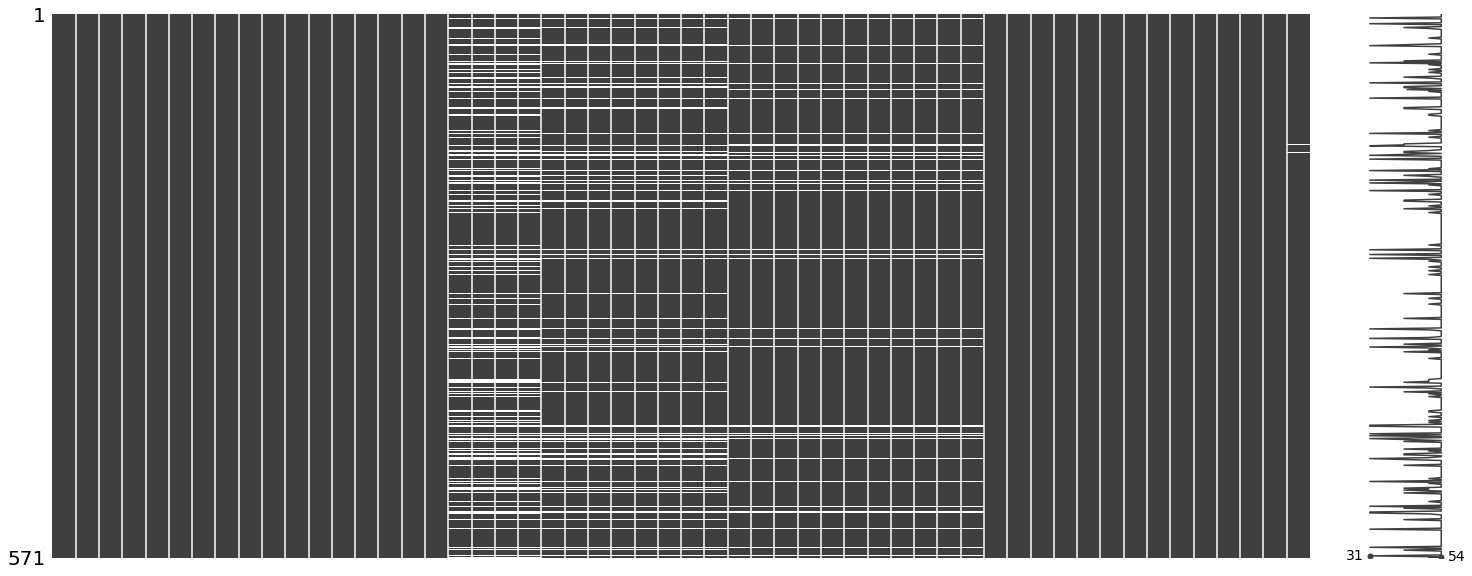

In [13]:
missingno.matrix(dataset)

In [14]:
cols = dataset.columns

In [15]:
cols

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'population', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi',
       'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std',
       'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst', 'lst_day', 'lst_night',
       'lst_jan_day_mean', 'lst_jan_night_mean', 'lst_feb_day_mean',
       'lst_feb_night_mean', 'lst_mar_day_mean', 'lst_mar_night_mean',
       'lst_apr_day_mean', 'lst_apr_night_mean', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'mosq_pred', 'mosq_previous',
       'case', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m'],
      dtype='object')

In [16]:
len(cols)

54

In [17]:
rearranged = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'population',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'mosq_pred', 'mosq_previous', 'case']

In [18]:
len(rearranged)

54

In [19]:
dataset = dataset[rearranged]

In [20]:
dataset.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2023-May-2nd.csv", encoding = enc, index = False)